 # SVM

In [1]:
from sklearn import datasets
import pandas as pd
import seaborn as sns

In [28]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

In [3]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Plotar em pares para vizualização

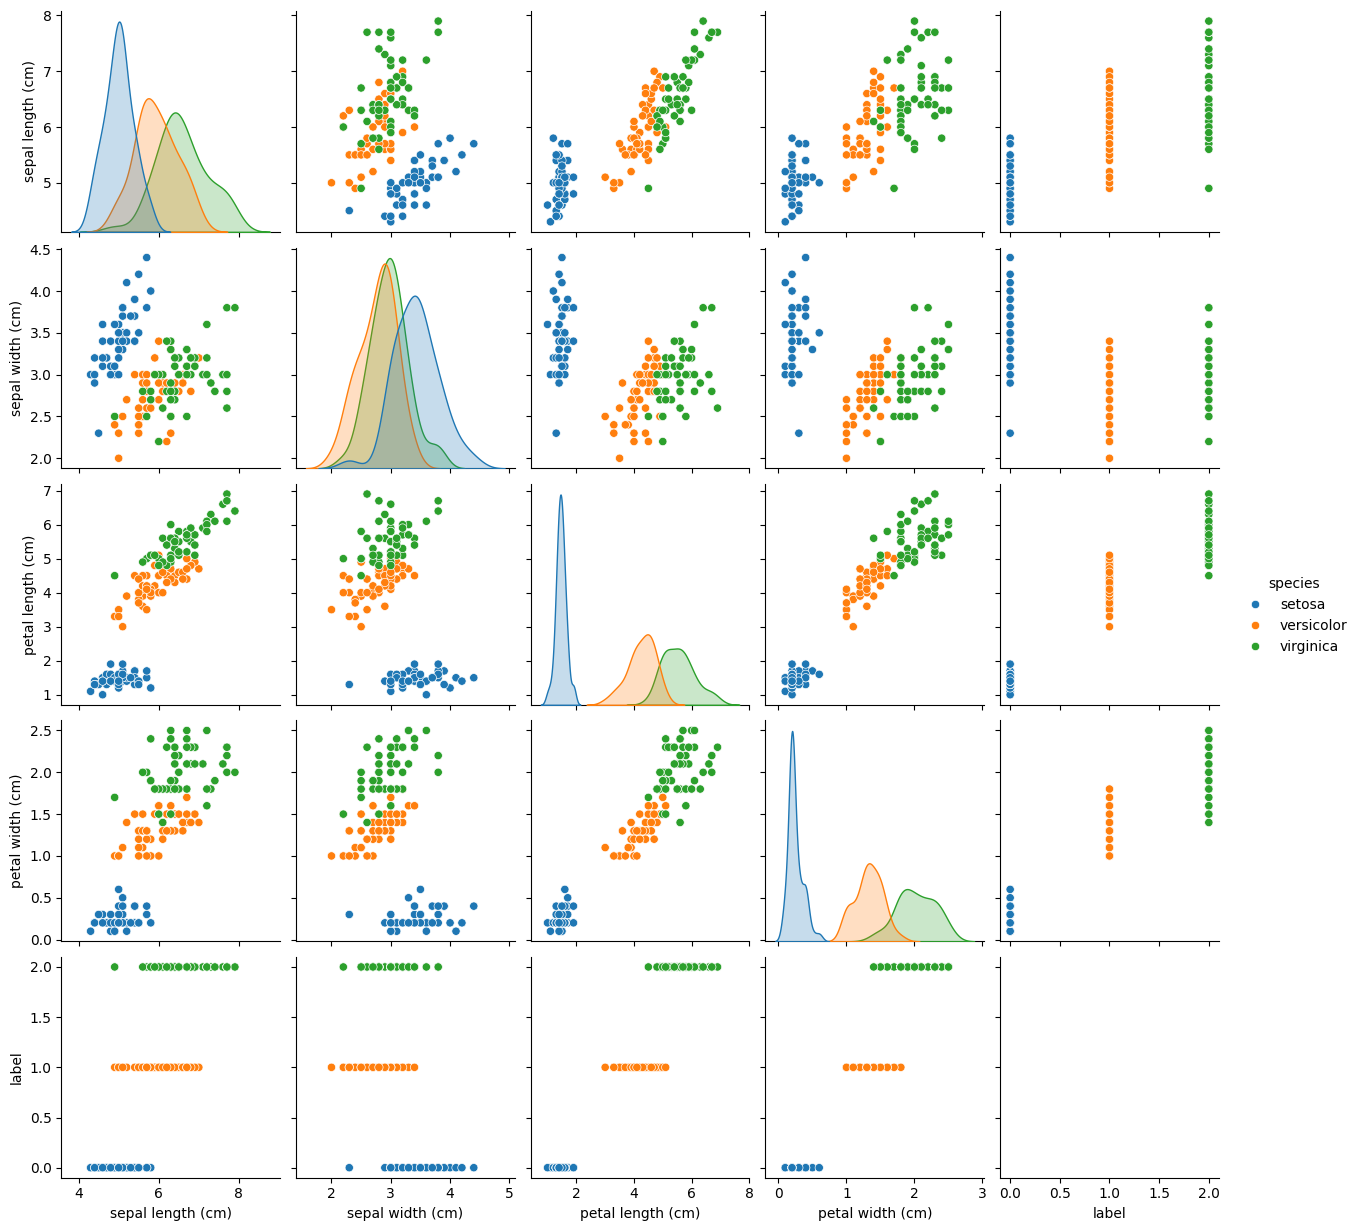

In [4]:
sns.pairplot(iris_df, hue='species')

In [5]:
from sklearn import svm
from sklearn.model_selection import train_test_split

In [6]:
X = iris.data
y = iris.target

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
clf = svm.SVC(kernel='linear', C=1.0)

In [9]:
clf.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
y_pred = clf.predict(X_test)

In [11]:
clf.score(X_test,y_test)

1.0

In [12]:
from sklearn.metrics import classification_report

In [13]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45




#  Kernel SVM (RBF e Polinomial)


Usaremos o **Kernel Trick** com `SVC` do scikit-learn e integraremos **pré-processamento + modelo** via `Pipeline`.


In [14]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report



## 1) Dados não lineares — `make_moons`
Criaremos um dataset com duas "luas" entrelaçadas (não separáveis linearmente).


In [15]:

# Geração do dataset
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X[:5], y[:5]


(array([[ 0.62546021,  1.03912171],
        [ 0.69888658, -0.4340313 ],
        [ 1.57700085,  0.05444021],
        [ 0.91174471,  0.66519838],
        [-0.31387334,  0.65169556]]),
 array([0, 1, 1, 0, 0]))


## 2) Função auxiliar de visualização (fronteira de decisão)
Usaremos uma função para plotar as regiões de decisão de qualquer classificador 2D.


In [18]:

def plot_decision_regions(model, X, y, title):
    # Define grade
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6.5, 5.5))
    # Contorno/área de decisão (pseudocores padrão do matplotlib)
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.9)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()



## 3) Pipeline + SVM RBF (baseline)
`StandardScaler` é importante pois SVM é sensível à escala das variáveis.


In [19]:

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_rbf.fit(X_train, y_train)
y_pred = svm_rbf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}  |  Recall: {rec:.4f}  |  F1: {f1:.4f}")
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
cm


Acurácia: 0.9267
Precisão: 0.9103  |  Recall: 0.9467  |  F1: 0.9281

Relatório de classificação:
               precision    recall  f1-score   support

           0       0.94      0.91      0.93        75
           1       0.91      0.95      0.93        75

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150



array([[68,  7],
       [ 4, 71]])

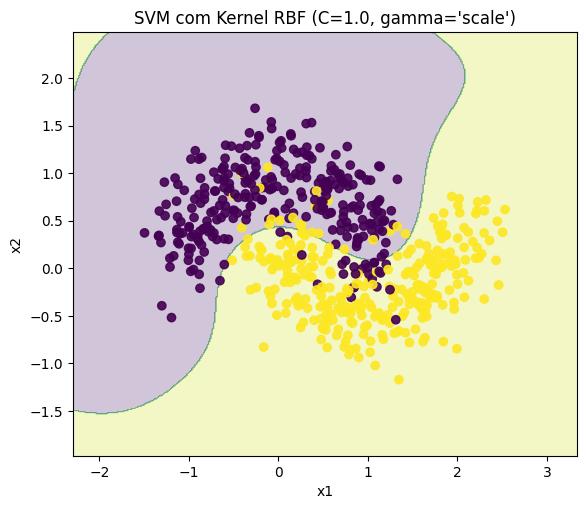

In [20]:
# Fronteira de decisão no conjunto completo
plot_decision_regions(svm_rbf, X, y, "SVM com Kernel RBF (C=1.0, gamma='scale')")


## 4) Efeito dos hiperparâmetros **C** e **γ**
- **C** (regularização): maior → margem menor, busca classificar tudo corretamente (risco de overfitting).  
- **γ** (gamma): maior → fronteira mais complexa; menor → fronteira mais suave.


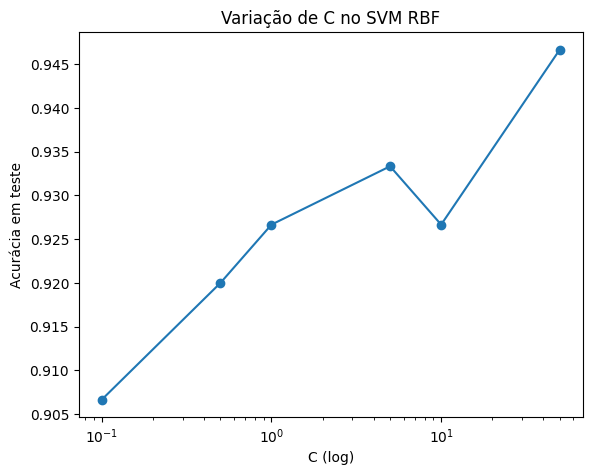

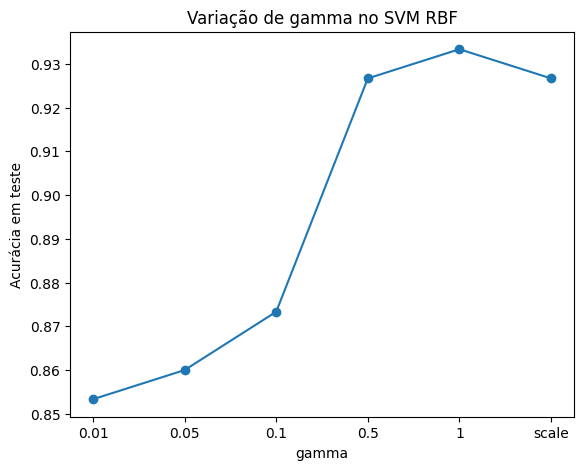

In [21]:

def sweep_param(param_name, values, base_C=1.0, base_gamma="scale"):
    scores = []
    for val in values:
        if param_name == "C":
            model = Pipeline([("scaler", StandardScaler()),
                              ("svc", SVC(kernel="rbf", C=val, gamma=base_gamma, random_state=42))])
        else:
            model = Pipeline([("scaler", StandardScaler()),
                              ("svc", SVC(kernel="rbf", C=base_C, gamma=val, random_state=42))])
        model.fit(X_train, y_train)
        y_hat = model.predict(X_test)
        scores.append(accuracy_score(y_test, y_hat))
    return np.array(scores)

Cs = [0.1, 0.5, 1, 5, 10, 50]
Gs = [0.01, 0.05, 0.1, 0.5, 1, "scale"]

acc_C = sweep_param("C", Cs, base_gamma="scale")
acc_G = sweep_param("gamma", Gs, base_C=1.0)

plt.figure(figsize=(6.5,5))
plt.plot(Cs, acc_C, marker="o")
plt.xscale("log")
plt.xlabel("C (log)")
plt.ylabel("Acurácia em teste")
plt.title("Variação de C no SVM RBF")
plt.show()

# Para gamma: converter 'scale' para rótulo posicional no eixo
plt.figure(figsize=(6.5,5))
x_positions = np.arange(len(Gs))
plt.plot(x_positions, acc_G, marker="o")
plt.xticks(x_positions, [str(g) for g in Gs], rotation=0)
plt.xlabel("gamma")
plt.ylabel("Acurácia em teste")
plt.title("Variação de gamma no SVM RBF")
plt.show()



## 5) Kernel Polinomial
Mostramos rapidamente o kernel **polinomial** e comparamos a acurácia.


Acurácia (kernel polinomial, grau=3): 0.9267


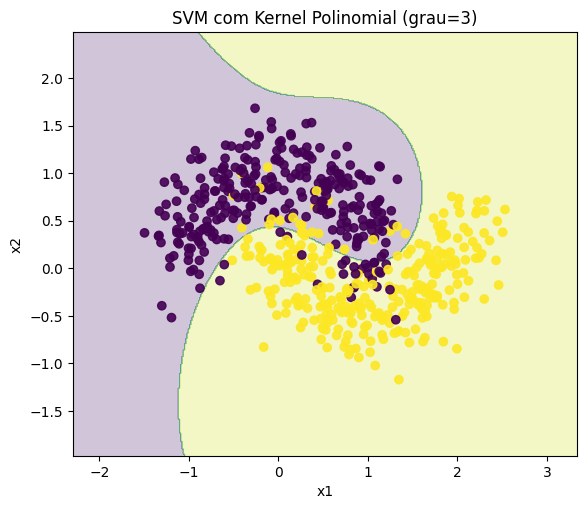

In [26]:

svm_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="poly", degree=3, C=1.0, coef0=1.0, gamma="scale", random_state=42))
])
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, y_pred_poly)
print(f"Acurácia (kernel polinomial, grau=3): {acc_poly:.4f}")

plot_decision_regions(svm_poly, X, y, "SVM com Kernel Polinomial (grau=3)")



## 6) Seleção de hiperparâmetros com GridSearchCV
Pesquisaremos boas combinações de **C** e **γ** (kernel RBF).


Melhores parâmetros: {'svc__C': 50, 'svc__gamma': 0.5}
Acurácia média (cv): 0.9422
Acurácia em teste (melhor modelo): 0.9467


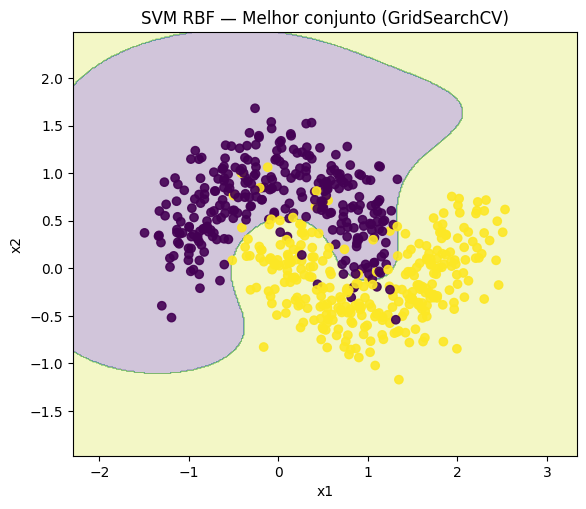

In [27]:

pipe = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf", random_state=42))])

param_grid = {
    "svc__C": [0.1, 1, 5, 10, 50],
    "svc__gamma": [0.01, 0.05, 0.1, 0.5, "scale"]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Acurácia média (cv):", round(grid.best_score_, 4))

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Acurácia em teste (melhor modelo):", round(accuracy_score(y_test, y_pred_best), 4))

plot_decision_regions(best_model, X, y, "SVM RBF — Melhor conjunto (GridSearchCV)")



## 7) Exercício (para os alunos)
1. Troque o dataset para **`make_circles`** (ou use `sklearn.datasets.load_wine`).  
2. Reaplique o pipeline com SVM **RBF** e depois **polinomial**.  
3. Varie **C** e **γ** (e, no polinomial, **degree**).  
4. Compare acurácia, precisão, recall, F1 e **desenhe as fronteiras de decisão**.  
5. Explique em 5 linhas qual kernel e hiperparâmetros funcionaram melhor e por quê.


In [ ]:

# === ESPAÇO DO ALUNO ===
# Exemplo de ponto de partida:
# from sklearn.datasets import make_circles
# X2, y2 = make_circles(n_samples=600, factor=0.4, noise=0.2, random_state=7)
# X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42, stratify=y2)
# model2 = Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf", C=5, gamma="scale"))])
# model2.fit(X2_train, y2_train)
# y2_pred = model2.predict(X2_test)
# print('Acurácia:', accuracy_score(y2_test, y2_pred))
# plot_decision_regions(model2, X2, y2, "Fronteira — RBF em make_circles")
